In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
import tkinter as tk
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2023-02-01


'2023-02-01'

In [3]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

taxol ='[Epothilone D] ' r'$(\mu M)$' #'[Taxol] ' r'$(\mu M)$' #'[Docetaxol] ' r'$(\mu M)$'
tax = 'epoD'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

In [4]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
darkyellow= '#FCF2B8'
yellow = '#FFCB05'
lightyellow = '#FCF2B8'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))


palette = [grey,cyan] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green]
parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

StartHue3 = Color(lightyellow)
Yellowcolor = list(StartHue3.range_to(Color(darkyellow),5))
Yellowpalette = list(map(Color.get_hex,Yellowcolor))
Yellowpalette

['#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8', '#fcf2b8']

## Import Kappa csv ##

In [58]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [59]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i.stem).rfind(tax) != -1]
folders

[WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH1_epoD0.3uM'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH2_epoD0.3uM'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH3_epoD0.1uM'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH4_epoD0.1uM')]

In [60]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('final') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH1_epoD0.3uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH1_epoD0.3uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH2_epoD0.3uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH2_epoD0.3uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH3_epoD0.1uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH3_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH4_epoD0.1uM/1-Stack_Composite-final-1-plain.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH4_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv')]

In [61]:
files1 = [i for i in files if str(i).rfind('1-plain') != -1 ]
files2 = [i for i in files if str(i).rfind('2-'+tax) != -1 ]
#files3 = [i for i in files if str(i).rfind('3dcx') != -1 ]
files2

[WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH1_epoD0.3uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH2_epoD0.3uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH3_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv'),
 WindowsPath('D:/Sofia/2023_1winter/2023-01-25_doublecap_EpoD/CH4_epoD0.1uM/1-Stack_Composite-final-2-epoD.csv')]

In [62]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [63]:
dates= []
CH= []
taxl= []
dcx = []
dcxtype= []
for i in files1:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    #dcx0 = findmetadata("DCX",'nM',i)
    #dcx = dcx + [dcx0] 
    
    #type0 = findmetadata("type",'_',i)
    #dcxtype = dcxtype + [type0] 
    
    taxl0 = findmetadata(tax,'uM',i)
    taxl = taxl + [taxl0] 
    

dates,CH,dcx, dcxtype,taxl

(['2023-01-25', '2023-01-25', '2023-01-25', '2023-01-25'],
 ['1', '2', '3', '4'],
 [],
 [],
 ['0.3', '0.3', '0.1', '0.1'])

In [64]:
def keep_avg_kappa(file,i,timepoint):
    data = pd.read_csv(file, encoding='utf-8')
    
    keep_columns = ['Curve Name','Curve Length (um)']
    
    data_avg = data.drop_duplicates(subset ='Curve Length (um)', keep = 'first')
    data_avg = data_avg[keep_columns]
    
    if timepoint == 'plain':
        data_avg[taxol]=0
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
    if timepoint == 'tax':
        data_avg[taxol]=float(taxl[i])
        data_avg[DCXconc]=0
        data_avg[Type]='None'
        
#     if timepoint == 'dcx':
#         data_avg[taxol]=float(tax[i])
#         data_avg[DCXconc]=float(dcx[i])
#         data_avg[Type]=dcxtype[i]
                
        
    data_avg['Date']=dates[i]
    data_avg['CH']=CH[i]
    
    return data_avg

In [65]:
data = pd.DataFrame(columns=[] , index=[])
for i in range(0,len(files1)):
    
    data_1plain_avg = keep_avg_kappa(files1[i],i,'plain')
    data_2tax_avg = keep_avg_kappa(files2[i],i,'tax')
    #data_3dcx_avg = keep_avg_kappa(files3[i],i,'dcx')

    data0 = pd.concat([data_1plain_avg, data_2tax_avg], ignore_index=True)

    data0 = data0.sort_values(['Curve Name',taxol,DCXconc])

    data = pd.concat([data,data0], ignore_index=True)

In [66]:
data

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,6.443508,0.0,0,None,2023-01-25,1
1,CURVE 1,6.619862,0.3,0,None,2023-01-25,1
2,CURVE 2,5.719402,0.0,0,None,2023-01-25,1
3,CURVE 2,5.866976,0.3,0,None,2023-01-25,1
4,CURVE 3,6.624258,0.0,0,None,2023-01-25,1
5,CURVE 3,6.817271,0.3,0,None,2023-01-25,1
6,CURVE 4,4.527208,0.0,0,None,2023-01-25,1
7,CURVE 4,4.607167,0.3,0,None,2023-01-25,1
8,CURVE 5,7.100226,0.0,0,None,2023-01-25,1
9,CURVE 5,7.295944,0.3,0,None,2023-01-25,1


In [67]:
path.parents[1]

WindowsPath('D:/Sofia')

In [68]:
newdirectory = str(path.parents[0])+'//Expansion_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets')

In [69]:
name = dates[0]+'_EpoD_expansion_analysed-on_'+date_today +'.csv'
name

'2023-01-25_EpoD_expansion_analysed-on_2023-02-01.csv'

In [70]:
data.to_csv(path/(name), encoding='utf-8', index=False)
data.to_csv(newmydir/(name), encoding='utf-8', index=False)

### JOIN ###

In [71]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [72]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if str(i).rfind('EpoD') != -1]
files = [i for i in files if str(i).rfind('Sheet.csv') == -1 if str(i).rfind('csv') != -1]
files

[WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-19_EpoD_expansion_analysed-on_2023-02-01.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-24_EpoD_expansion_analysed-on_2023-02-01.csv'),
 WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-25_EpoD_expansion_analysed-on_2023-02-01.csv')]

In [73]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('jointdata-on_'+date_today +'_Doce_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,11.829896,0.0,0,None,2023-01-19,1
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
2,CURVE 2,7.579007,0.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
4,CURVE 3,6.910134,0.0,0,None,2023-01-19,1
...,...,...,...,...,...,...,...
105,CURVE 1,13.315024,0.1,0,None,2023-01-25,4
106,CURVE 2,12.560515,0.0,0,None,2023-01-25,4
107,CURVE 2,12.568291,0.1,0,None,2023-01-25,4
108,CURVE 3,11.483431,0.0,0,None,2023-01-25,4


In [74]:
# plainData = joindata.iloc[:-2:3]
# taxData = joindata.iloc[1:-1:3]
# dcxData = joindata.iloc[2::3]
plainData = joindata.iloc[:-1:2]
taxData = joindata.iloc[1::2]

In [75]:
taxData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1
11,CURVE 6,9.153798,10.0,0,None,2023-01-19,1
13,CURVE 7,10.420932,10.0,0,None,2023-01-19,1
15,CURVE 1,9.149766,10.0,0,None,2023-01-19,2
17,CURVE 2,10.046771,10.0,0,None,2023-01-19,2
19,CURVE 3,6.267830,10.0,0,None,2023-01-19,2


In [76]:
def percent_expansion(beforeData, afterData):
    ratio = beforeData['Curve Length (um)'].values / afterData['Curve Length (um)'].values
    prcnt_expansion = (1- ratio)*100
    afterData['Expansion %'] = prcnt_expansion
    return afterData

In [77]:
percent_expansion(plainData, taxData)
#percent_expansion(plainData, dcxData)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518
11,CURVE 6,9.153798,10.0,0,None,2023-01-19,1,2.239670
13,CURVE 7,10.420932,10.0,0,None,2023-01-19,1,2.809237
15,CURVE 1,9.149766,10.0,0,None,2023-01-19,2,1.933854
17,CURVE 2,10.046771,10.0,0,None,2023-01-19,2,1.265010
19,CURVE 3,6.267830,10.0,0,None,2023-01-19,2,3.262784


In [78]:
finalData = taxData
finalData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518
11,CURVE 6,9.153798,10.0,0,None,2023-01-19,1,2.239670
13,CURVE 7,10.420932,10.0,0,None,2023-01-19,1,2.809237
15,CURVE 1,9.149766,10.0,0,None,2023-01-19,2,1.933854
17,CURVE 2,10.046771,10.0,0,None,2023-01-19,2,1.265010
19,CURVE 3,6.267830,10.0,0,None,2023-01-19,2,3.262784


In [84]:
finalData['Curve Length (um)'] > 5

1       True
3       True
5       True
7       True
9       True
11      True
13      True
15      True
17      True
19      True
21      True
23      True
25      True
27      True
29      True
31      True
33      True
35      True
37      True
39      True
41      True
43      True
45      True
47      True
49      True
51      True
53      True
55      True
57      True
59      True
61      True
63      True
65      True
67      True
69      True
71      True
73     False
75      True
77      True
79      True
81      True
83      True
85     False
87      True
89     False
91      True
93      True
95      True
97      True
99      True
101    False
103    False
105     True
107     True
109     True
Name: Curve Length (um), dtype: bool

In [80]:
finalData.to_csv(path/('expansion_plain_to_EpoD_data-analyzed_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)

## LOAD DATA ##

In [118]:
askfile = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
filepath = Path(askfile)
filename = filepath.stem
filepath, filename

(WindowsPath('D:/Sofia/2023_1winter/Expansion_Data_Sheets/2023-01-19_EpoD_expansion_analysed-on_2023-01-20.csv'),
 '2023-01-19_EpoD_expansion_analysed-on_2023-01-20')

In [119]:
finalData = pd.read_csv(filepath, encoding='utf-8')
finalData

,Curve Name,Curve Length (um),[Epothilone D] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH
0,CURVE 1,11.829896,0.0,0,None,2023-01-19,1
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1
2,CURVE 2,7.579007,0.0,0,None,2023-01-19,1
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1
4,CURVE 3,6.910134,0.0,0,None,2023-01-19,1
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1
6,CURVE 4,6.463798,0.0,0,None,2023-01-19,1
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1
8,CURVE 5,7.460618,0.0,0,None,2023-01-19,1
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1


In [61]:
path = filepath.parents[0]

## PLOT DATA ##

In [53]:
nogales2018 = (1- 81.76/83.95)*100
nogales2018

2.608695652173909

In [54]:
nogales2017 = (1- 81.5/83.2)*100
nogales2017


2.043269230769229

In [55]:
TAXnogales2017preformed = (1- 81.5/81.8)*100
TAXnogales2017copoly = (1- 81.5/82.3)*100
TAXnogales2017preformed , TAXnogales2017copoly


(0.3667481662591676, 0.9720534629404587)

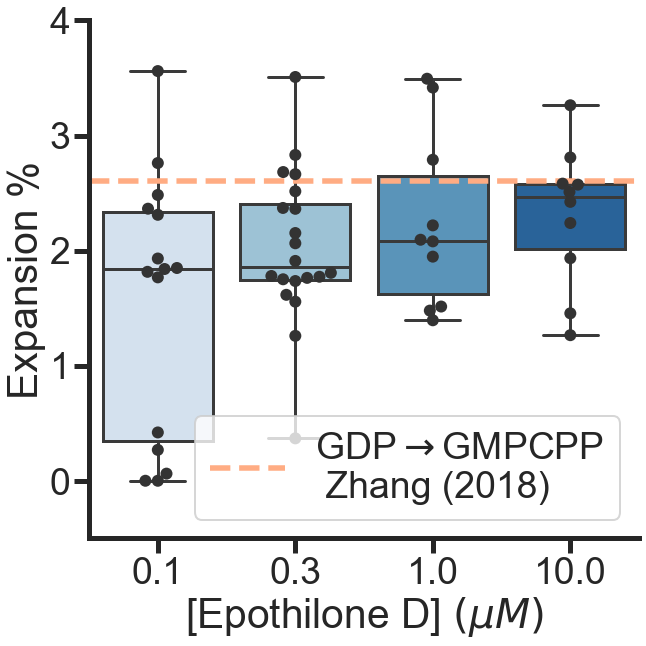

In [81]:
fig, ax = plt.subplots(1,1,figsize=(10,10))

#rect = 0,0,1,1 # create an rectangle for the new axis
#log_ax = fig.add_axes(rect) # create a new axis (or use an existing one)
#log_ax.set_xscale("log") # log first

ax = sns.boxplot(x= taxol, y='Expansion %', data=finalData, whis=np.inf, palette='Blues',linewidth=3)
ax = sns.swarmplot(x=taxol, y='Expansion %', data=finalData, color=".2", size=12)

ax.axhline(y = nogales2018, color = lightorange ,linestyle="--", linewidth=5.5, label='GDP'r'$\rightarrow$''GMPCPP \n Zhang (2018)')
#plt.xlim(0.1,10)

ax.set_ylim(-0.5,4)
ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(taxol)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


plt.savefig(path/('expansion_'+date_today+'.svg'))

In [40]:
(1- 81.76/83.95)*100

2.608695652173909

In [65]:
finalData.groupby([taxol,'CH','Date']).size()

[Taxol] $(\mu M)$  CH   Date      
0.0                CH1  2022-05-25    23
0.1                CH1  2022-05-13     5
                   CH2  2022-05-13     7
0.3                CH2  2022-05-25     4
                   CH3  2022-05-25     5
                   CH4  2022-05-25     2
1.0                CH3  2022-05-13     3
                   CH4  2022-05-13     4
                   CH5  2022-05-25     1
10.0               CH2  2022-05-03    10
dtype: int64

In [66]:
finalData.groupby(taxol).size()

[Taxol] $(\mu M)$
0.0     23
0.1     12
0.3     11
1.0      8
10.0    10
dtype: int64

## change drug name to merge##

In [112]:
drug = '[Drug] ' r'$(\mu M)$'
drugtype = 'Drug Type'


In [113]:
finalData=finalData.rename({taxol: drug}, axis=1)
finalData[drugtype] = 'Epothilone D'

In [114]:
finalData

,Curve Name,Curve Length (um),[Drug] $(\mu M)$,[DCX] $(n M)$,DCX Type,Date,CH,Expansion %,Drug Type
1,CURVE 1,12.143414,10.0,0,None,2023-01-19,1,2.581796,Epothilone D
3,CURVE 2,7.774119,10.0,0,None,2023-01-19,1,2.509758,Epothilone D
5,CURVE 3,7.012163,10.0,0,None,2023-01-19,1,1.455021,Epothilone D
7,CURVE 4,6.634512,10.0,0,None,2023-01-19,1,2.573112,Epothilone D
9,CURVE 5,7.645918,10.0,0,None,2023-01-19,1,2.423518,Epothilone D
11,CURVE 6,9.153798,10.0,0,None,2023-01-19,1,2.239670,Epothilone D
13,CURVE 7,10.420932,10.0,0,None,2023-01-19,1,2.809237,Epothilone D
15,CURVE 1,9.149766,10.0,0,None,2023-01-19,2,1.933854,Epothilone D
17,CURVE 2,10.046771,10.0,0,None,2023-01-19,2,1.265010,Epothilone D
19,CURVE 3,6.267830,10.0,0,None,2023-01-19,2,3.262784,Epothilone D


In [115]:
name = 'expansion_plain_to_EpoD_data-for-merge_'+date_today +'_MasterSheet.csv'
finalData.to_csv(path/(name), encoding='utf-8', index=False)

## Merge different drugs ##

In [116]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [74]:
files = [x for x in path.iterdir() if x.is_file()]
files = [i for i in files if str(i).rfind('merge') != -1]
files = [i for i in files if str(i).rfind('csv') != -1]
files

[WindowsPath('D:/Sofia/2022_2summer-fall/Expansion_Data_Sheets/expansion_plain_to_Doce_data-for-merge_2023-01-17_MasterSheet.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Expansion_Data_Sheets/expansion_plain_to_Pacli_data-for-merge_2023-01-17_MasterSheet.csv'),
 WindowsPath('D:/Sofia/2022_2summer-fall/Expansion_Data_Sheets/expansion_plain_to_SiR_data-for-merge_2023-01-17_MasterSheet.csv')]

In [75]:
joindata = pd.read_csv(files[0], encoding='utf-8')
for i in range(1,len(files)):
    d = pd.read_csv(files[i], encoding='utf-8')
    joindata = joindata.append(d, ignore_index=True)

joindata.to_csv(path/('merge-drug-data-on_'+date_today +'_MasterSheet.csv'), encoding='utf-8', index=False)
joindata

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:7123: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  sort=sort,


,CH,Curve Length (um),Curve Name,DCX Type,Date,Drug Type,Expansion %,[DCX] $(n M)$,[Drug] $(\mu M)$
0,3,11.902069,CURVE 1,None,2022-11-29,Docetaxel,2.116323,0.0,1.0
1,3,9.049524,CURVE 10,None,2022-11-29,Docetaxel,2.758230,0.0,1.0
2,3,8.572491,CURVE 11,None,2022-11-29,Docetaxel,2.975848,0.0,1.0
3,3,11.344865,CURVE 2,None,2022-11-29,Docetaxel,2.366607,0.0,1.0
4,3,9.375803,CURVE 3,None,2022-11-29,Docetaxel,3.333469,0.0,1.0
...,...,...,...,...,...,...,...,...,...
154,2,8.566150,CURVE 3,None,2022-11-10,SiR-tubulin,-0.008393,0.0,10.0
155,2,9.428532,CURVE 4,None,2022-11-10,SiR-tubulin,0.018932,0.0,10.0
156,2,7.548724,CURVE 5,None,2022-11-10,SiR-tubulin,-0.027145,0.0,10.0
157,2,10.715951,CURVE 6,None,2022-11-10,SiR-tubulin,0.499633,0.0,10.0


C:\Users\Brouhard Lab\AppData\Roaming\Python\Python37\site-packages\seaborn\categorical.py:1296: UserWarning: 47.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Brouhard Lab\AppData\Roaming\Python\Python37\site-packages\seaborn\categorical.py:1296: UserWarning: 46.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


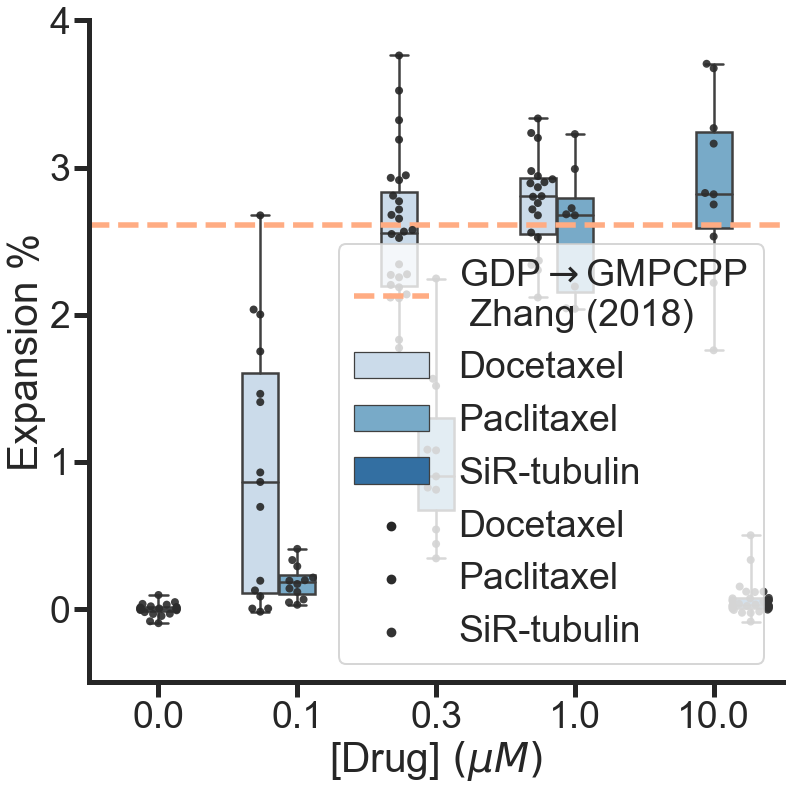

In [80]:
fig, ax = plt.subplots(1,1,figsize=(12,12))

#rect = 0,0,1,1 # create an rectangle for the new axis
#log_ax = fig.add_axes(rect) # create a new axis (or use an existing one)
#log_ax.set_xscale("log") # log first

ax = sns.boxplot(x= drug, y='Expansion %',hue=drugtype, data=joindata, whis=np.inf,linewidth=2.5, palette='Blues')
ax = sns.swarmplot(x=drug, y='Expansion %',hue=drugtype, data=joindata, color=".2", size=8, dodge=True, alpha=0.9)

ax.axhline(y = nogales2018, color = lightorange ,linestyle="--", linewidth=5.5, label='GDP'r'$\rightarrow$''GMPCPP \n Zhang (2018)')
#plt.xlim(0.1,10)

ax.set_ylim(-0.5,4)
ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(drug)

sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


plt.savefig(path/('mergedrugs_'+date_today+'.svg'))

In [16]:
import matplotlib
print(matplotlib.__version__)

3.4.3
